In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.faers_loader import create_demo_dataset

sns.set_theme(style='whitegrid')
df = create_demo_dataset(n_samples=5000, save=False)
print(f'Dataset shape: {df.shape}')
df.head()

2026-06-11 17:39:36.749 | INFO     | src.data.faers_loader:create_demo_dataset:193 - Demo dataset: 5,000 samples, 52.56% serious


Dataset shape: (5000, 17)


,primaryid,age,sex,wt,occr_country,drug_seq,dose_amt,dose_freq,dur,dechal,rechal,drugname,route,prod_ai,reactions,quarter,serious
0,0,63,M,56.230658,FR,4,100,TID,344,Y,N,Warfarin,intravenous,Amoxicillin,anaphylaxis | nausea,demo,1
1,1,52,M,64.071848,JP,7,25,PRN,255,U,Y,Aspirin,oral,Omeprazole,bleeding | nausea | chest pain,demo,1
2,2,66,F,69.355188,DE,8,500,BID,45,N,U,Metoprolol,subcutaneous,Amoxicillin,liver injury,demo,1
3,3,82,M,96.015486,DE,8,25,QD,316,U,N,Atorvastatin,intravenous,Lisinopril,dizziness | dyspnea,demo,1
4,4,50,M,51.741220,GB,8,25,QD,86,N,N,Ibuprofen,oral,Warfarin,headache,demo,0


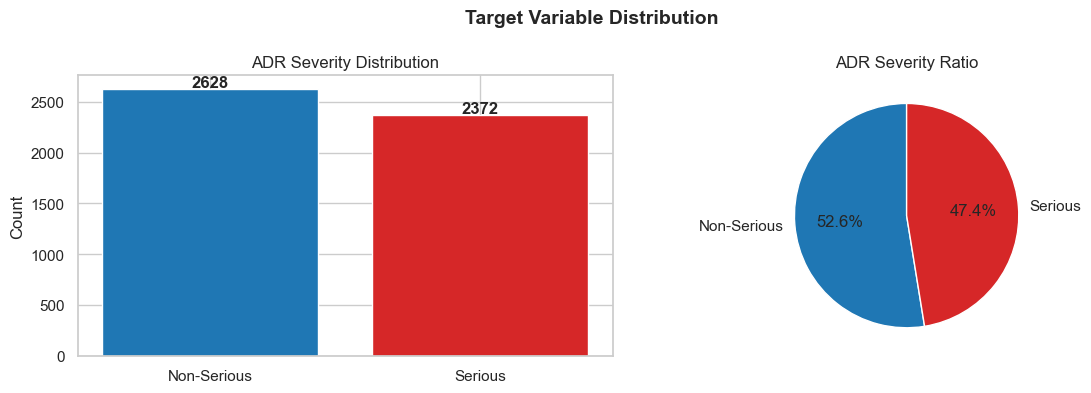

Serious ADR rate: 52.56%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['serious'].value_counts()
axes[0].bar(['Non-Serious', 'Serious'], counts.values, color=['#1f77b4', '#d62728'])
axes[0].set_title('ADR Severity Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Non-Serious', 'Serious'],
            colors=['#1f77b4', '#d62728'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('ADR Severity Ratio')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Serious ADR rate: {df["serious"].mean():.2%}')

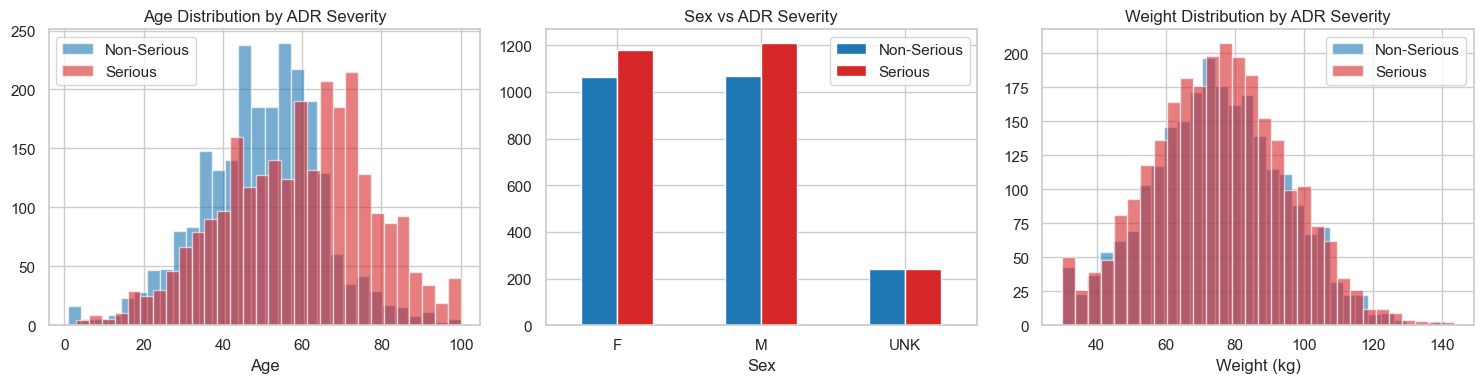

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(df[df['serious']==0]['age'], bins=30, alpha=0.6, label='Non-Serious', color='#1f77b4')
axes[0].hist(df[df['serious']==1]['age'], bins=30, alpha=0.6, label='Serious', color='#d62728')
axes[0].set_title('Age Distribution by ADR Severity')
axes[0].set_xlabel('Age')
axes[0].legend()

# Sex distribution
sex_serious = df.groupby(['sex', 'serious']).size().unstack(fill_value=0)
sex_serious.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#d62728'], rot=0)
axes[1].set_title('Sex vs ADR Severity')
axes[1].set_xlabel('Sex')
axes[1].legend(['Non-Serious', 'Serious'])

# Weight distribution
axes[2].hist(df[df['serious']==0]['wt'], bins=30, alpha=0.6, label='Non-Serious', color='#1f77b4')
axes[2].hist(df[df['serious']==1]['wt'], bins=30, alpha=0.6, label='Serious', color='#d62728')
axes[2].set_title('Weight Distribution by ADR Severity')
axes[2].set_xlabel('Weight (kg)')
axes[2].legend()

plt.tight_layout()
plt.show()

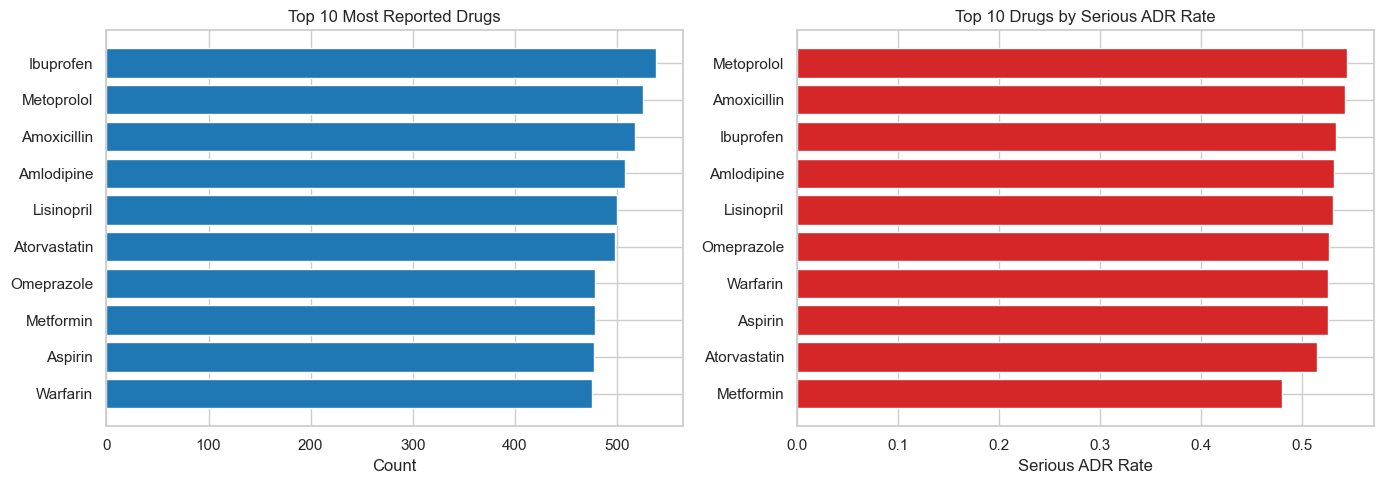

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top drugs by frequency
top_drugs = df['drugname'].value_counts().head(10)
axes[0].barh(top_drugs.index, top_drugs.values, color='#1f77b4')
axes[0].set_title('Top 10 Most Reported Drugs')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Serious rate per drug
drug_serious = df.groupby('drugname')['serious'].mean().sort_values(ascending=False).head(10)
axes[1].barh(drug_serious.index, drug_serious.values, color='#d62728')
axes[1].set_title('Top 10 Drugs by Serious ADR Rate')
axes[1].set_xlabel('Serious ADR Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

C:\Users\sanga\AppData\Local\Temp\ipykernel_23008\2302364195.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['serious']==0]['dose_amt'],


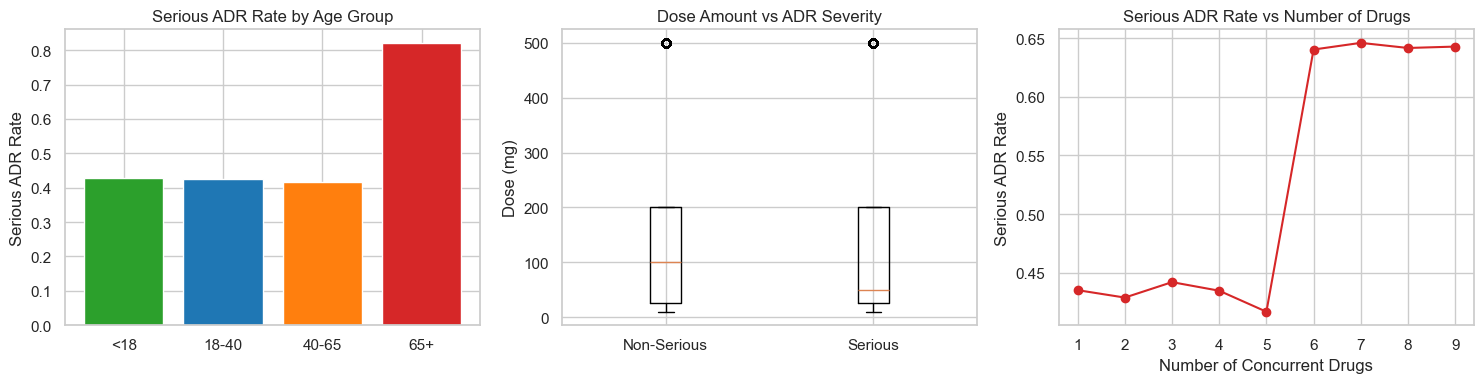

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age groups
df['age_group'] = pd.cut(df['age'], bins=[0,18,40,65,100],
                          labels=['<18', '18-40', '40-65', '65+'])
age_risk = df.groupby('age_group', observed=True)['serious'].mean()
axes[0].bar(age_risk.index.astype(str), age_risk.values, color=['#2ca02c','#1f77b4','#ff7f0e','#d62728'])
axes[0].set_title('Serious ADR Rate by Age Group')
axes[0].set_ylabel('Serious ADR Rate')

# Dose vs serious
axes[1].boxplot([df[df['serious']==0]['dose_amt'],
                 df[df['serious']==1]['dose_amt']],
                labels=['Non-Serious', 'Serious'])
axes[1].set_title('Dose Amount vs ADR Severity')
axes[1].set_ylabel('Dose (mg)')

# Number of drugs
drug_risk = df.groupby('drug_seq')['serious'].mean()
axes[2].plot(drug_risk.index, drug_risk.values, marker='o', color='#d62728')
axes[2].set_title('Serious ADR Rate vs Number of Drugs')
axes[2].set_xlabel('Number of Concurrent Drugs')
axes[2].set_ylabel('Serious ADR Rate')

plt.tight_layout()
plt.show()

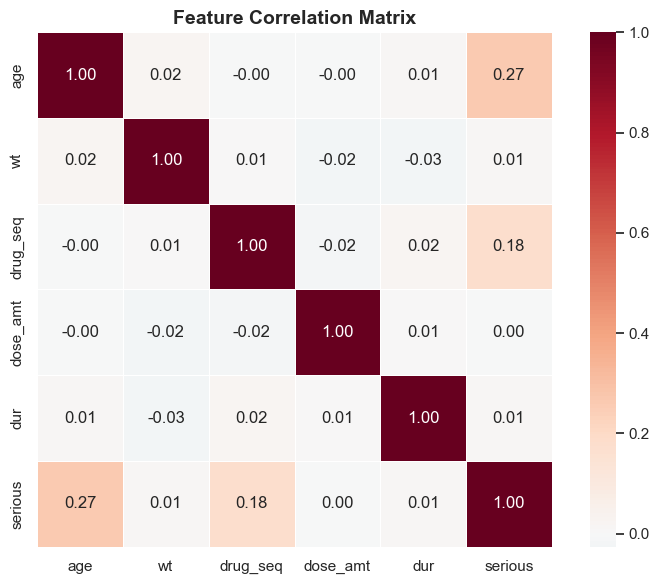

In [6]:
numeric_cols = ['age', 'wt', 'drug_seq', 'dose_amt', 'dur', 'serious']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
print("""
📊 KEY FINDINGS
===============

1. AGE is the strongest risk factor
   — Patients over 65 have significantly higher serious ADR rates

2. POLYPHARMACY increases risk
   — More concurrent drugs = higher serious ADR probability

3. DOSE AMOUNT matters
   — Higher doses correlate with more serious outcomes

4. SEX difference is small
   — Slight difference between M/F but not a dominant factor

5. DRUG TYPE matters significantly
   — Some drugs have 2-3x higher serious ADR rates than others
""")


📊 KEY FINDINGS

1. AGE is the strongest risk factor
   — Patients over 65 have significantly higher serious ADR rates

2. POLYPHARMACY increases risk
   — More concurrent drugs = higher serious ADR probability

3. DOSE AMOUNT matters
   — Higher doses correlate with more serious outcomes

4. SEX difference is small
   — Slight difference between M/F but not a dominant factor

5. DRUG TYPE matters significantly
   — Some drugs have 2-3x higher serious ADR rates than others

